In [14]:
# Install if needed
# !pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [15]:
# Question 1: Load dataset and initial analysis

df = pd.read_csv("Loan prediction.csv")

print(df.head(10))

print("Features:")
print(df.drop("Loan_Status", axis=1).columns.tolist())

print("Target Variable: Loan_Status")

print("Shape:", df.shape)

print("Missing Values:")
print(df.isnull().sum())

print("Statistical Summary:")
print(df.describe())

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   
5  LP001011   Male     Yes          2      Graduate           Yes   
6  LP001013   Male     Yes          0  Not Graduate            No   
7  LP001014   Male     Yes         3+      Graduate            No   
8  LP001018   Male     Yes          2      Graduate            No   
9  LP001020   Male     Yes          1      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000         

In [16]:
# Question 2: Data preprocessing

df_clean = df.copy()

# Drop Loan_ID because it is only an identifier
df_clean.drop("Loan_ID", axis=1, inplace=True)

# Fill missing categorical values with mode
categorical_cols = df_clean.select_dtypes(include="object").columns

for col in categorical_cols:
    df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

# Fill missing numerical values with median
numerical_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns

for col in numerical_cols:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)

# Convert target variable
df_clean["Loan_Status"] = df_clean["Loan_Status"].map({"Y": 1, "N": 0})

# Convert categorical variables using one-hot encoding
df_clean = pd.get_dummies(df_clean, drop_first=True)

# Create feature matrix X and target y
X = df_clean.drop("Loan_Status", axis=1)
y = df_clean["Loan_Status"]

# Standardize numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Final feature matrix shape:", X_scaled.shape)
print("Target shape:", y.shape)

Final feature matrix shape: (614, 14)
Target shape: (614,)


/var/folders/th/vmcd0q6s6t35th6859m8rtkm0000gn/T/ipykernel_2902/1057824826.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
/var/folders/th/vmcd0q6s6t35th6859m8rtkm0000gn/T/ipykernel_2902/1057824826.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting 

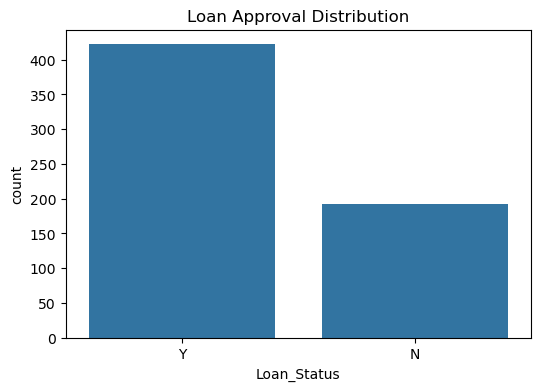

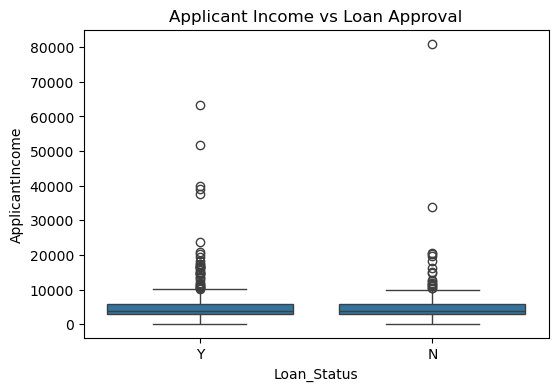

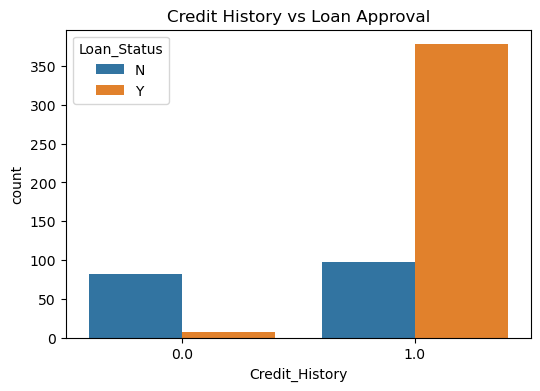

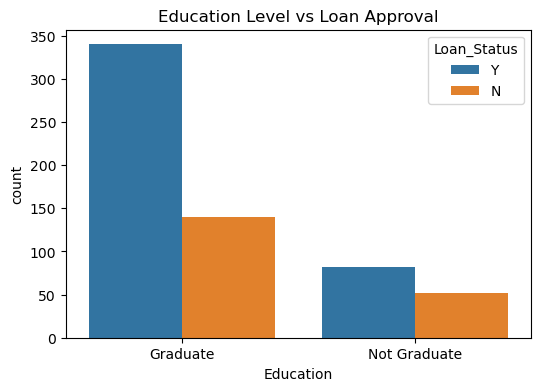

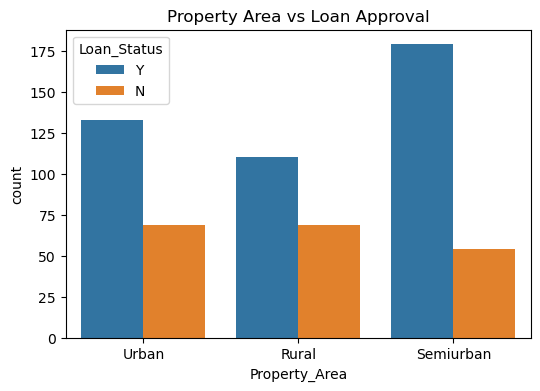

In [17]:
# Question 3: Exploratory Data Analysis

plt.figure(figsize=(6,4))
sns.countplot(x="Loan_Status", data=df)
plt.title("Loan Approval Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x="Loan_Status", y="ApplicantIncome", data=df)
plt.title("Applicant Income vs Loan Approval")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x="Credit_History", hue="Loan_Status", data=df)
plt.title("Credit History vs Loan Approval")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x="Education", hue="Loan_Status", data=df)
plt.title("Education Level vs Loan Approval")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x="Property_Area", hue="Loan_Status", data=df)
plt.title("Property Area vs Loan Approval")
plt.show()

In [18]:
# Question 4: Train-test split and model training

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.861789   0.840000  0.988235  0.908108
1        Decision Tree  0.715447   0.812500  0.764706  0.787879
2        Random Forest  0.837398   0.849462  0.929412  0.887640


In [19]:
# Question 5: Best model based on performance

best_model = results_df.sort_values(by="F1 Score", ascending=False).iloc[0]

print("Best Performing Model:")
print(best_model)

Best Performing Model:
Model        Logistic Regression
Accuracy                0.861789
Precision                   0.84
Recall                  0.988235
F1 Score                0.908108
Name: 0, dtype: object


In [20]:
# Question 6: Stratified 5-Fold Cross Validation

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=skf, scoring="accuracy")

    cv_results.append({
        "Model": name,
        "Fold Scores": scores,
        "Mean Accuracy": scores.mean(),
        "Standard Deviation": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)
print(cv_results_df)

                 Model                                        Fold Scores  \
0  Logistic Regression  [0.8211382113821138, 0.8048780487804879, 0.804...   
1        Decision Tree  [0.7479674796747967, 0.7235772357723578, 0.747...   
2        Random Forest  [0.7967479674796748, 0.7967479674796748, 0.764...   

   Mean Accuracy  Standard Deviation  
0       0.802972            0.025117  
1       0.723124            0.026734  
2       0.773637            0.027707  


In [21]:
# Question 7: Hyperparameter tuning using GridSearchCV

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 10],
    "min_samples_split": [2, 5, 10]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=skf,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("Best Cross-Validation Score:")
print(grid_search.best_score_)

best_rf = grid_search.best_estimator_

y_pred_tuned = best_rf.predict(X_test)

tuned_results = {
    "Accuracy": accuracy_score(y_test, y_pred_tuned),
    "Precision": precision_score(y_test, y_pred_tuned),
    "Recall": recall_score(y_test, y_pred_tuned),
    "F1 Score": f1_score(y_test, y_pred_tuned)
}

print("Tuned Random Forest Performance:")
print(tuned_results)

Best Parameters:
{'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 200}
Best Cross-Validation Score:
0.8003092145949289
Tuned Random Forest Performance:
{'Accuracy': 0.8536585365853658, 'Precision': 0.8316831683168316, 'Recall': 0.9882352941176471, 'F1 Score': 0.9032258064516129}


In [22]:
# Compare Random Forest before and after tuning

rf_before = results_df[results_df["Model"] == "Random Forest"]

comparison = pd.DataFrame({
    "Model": ["Random Forest Before Tuning", "Random Forest After Tuning"],
    "Accuracy": [rf_before["Accuracy"].values[0], tuned_results["Accuracy"]],
    "Precision": [rf_before["Precision"].values[0], tuned_results["Precision"]],
    "Recall": [rf_before["Recall"].values[0], tuned_results["Recall"]],
    "F1 Score": [rf_before["F1 Score"].values[0], tuned_results["F1 Score"]]
})

print(comparison)

                         Model  Accuracy  Precision    Recall  F1 Score
0  Random Forest Before Tuning  0.837398   0.849462  0.929412  0.887640
1   Random Forest After Tuning  0.853659   0.831683  0.988235  0.903226


In [23]:
# Question 8: Bias-Variance Tradeoff using Decision Tree depths

depths = [2, 5, 15]
bias_variance_results = []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)

    train_pred = dt.predict(X_train)
    test_pred = dt.predict(X_test)

    bias_variance_results.append({
        "Max Depth": depth,
        "Training Accuracy": accuracy_score(y_train, train_pred),
        "Testing Accuracy": accuracy_score(y_test, test_pred)
    })

bias_variance_df = pd.DataFrame(bias_variance_results)
print(bias_variance_df)

   Max Depth  Training Accuracy  Testing Accuracy
0          2           0.804481          0.853659
1          5           0.824847          0.829268
2         15           0.975560          0.731707


In [24]:
# Optional: Classification report for final tuned model

print(classification_report(y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.95      0.55      0.70        38
           1       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123

